In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [ ]:
# Install dependency
!pip install -q "kagglehub[pandas-datasets]"

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ealaxi/paysim1",
    "PS_20174392719_1491204439457_log.csv"
)

print("Dataset shape:", df.shape)
print("\nFirst 5 records:")
# display(df.head())

/tmp/ipykernel_1353/2680507586.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'paysim1' dataset.
Dataset shape: (6362620, 11)

First 5 records:


# Data Info

In [ ]:
print(df.shape)
print(df.columns.tolist())

(6362620, 11)
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
df.describe(include='object')

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C1530544995,C1286084959
freq,2237500,3,113


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

# Missing Values

In [ ]:
missing = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

display(missing_df)

,missing_count,missing_percentage
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [ ]:
df['isFraud'].value_counts(normalize=True)*100

,proportion
isFraud,
0,99.870918
1,0.129082


# EDA

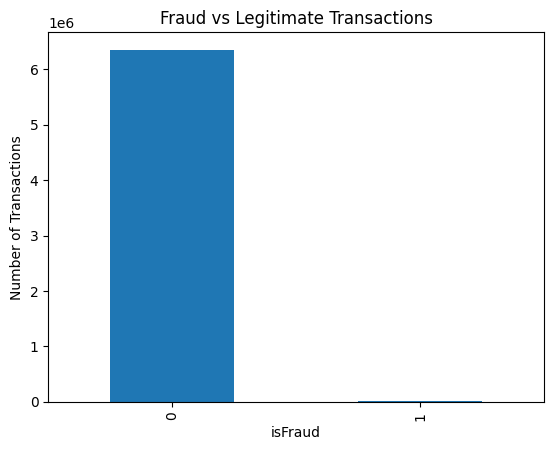

In [ ]:
import matplotlib.pyplot as plt

df["isFraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")

plt.show()

In [ ]:
# Fraud classification by different type of transations
pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


In [ ]:
pd.crosstab(
    df["type"],
    df["isFraud"]
)

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


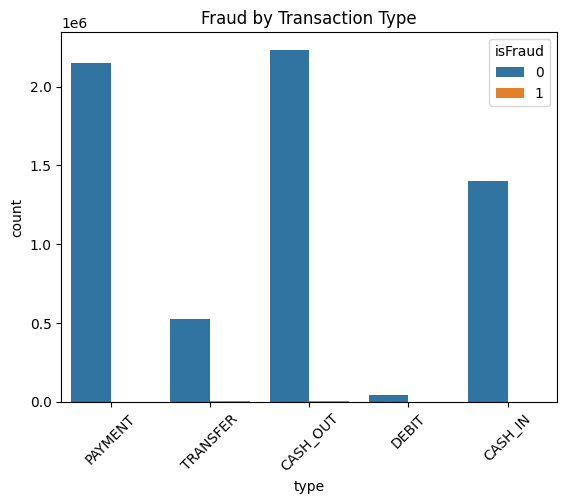

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="type",
    hue="isFraud"
)

plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)

plt.show()

## Amount Distribution

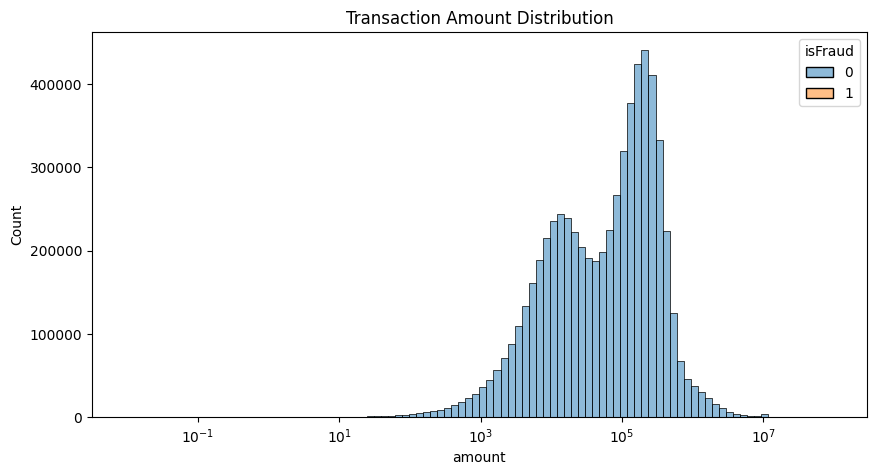

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=100,
    log_scale=True
)

plt.title("Transaction Amount Distribution")

plt.show()

In [ ]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


## New Features

In [ ]:
df["balance_error_orig"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

In [ ]:
df["balance_error_dest"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

In [ ]:
df[
    [
        "balance_error_orig",
        "balance_error_dest",
        "isFraud"
    ]
].groupby("isFraud").describe()

balance_error_orig                                             \
                     count           mean            std          min   
isFraud                                                                 
0                6354407.0 -201338.558109  606928.890826 -92445516.64   
1                   8213.0  -10692.325265  265146.131130 -10000000.00   

                                                     balance_error_dest  \
               25%       50%       75%           max              count   
isFraud                                                                   
0       -249953.43 -69049.31 -3034.305  1.000000e-02          6354407.0   
1             0.00      0.00     0.000  3.725290e-09             8213.0   

                                                                             \
                  mean           std          min  25%      50%         75%   
isFraud                                                                       
0         54692.231734  4.360026e+05 -75885725.63  0.0  3500.68   29259.805   
1        732509.301069  1.867748e+06  -8875516.29  0.0  2231.46  442722.010   

                      
                 max  
isFraud               
0        13191233.98  
1        10000000.00

## Correlation

In [ ]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

corr = df[numeric_cols].corr()

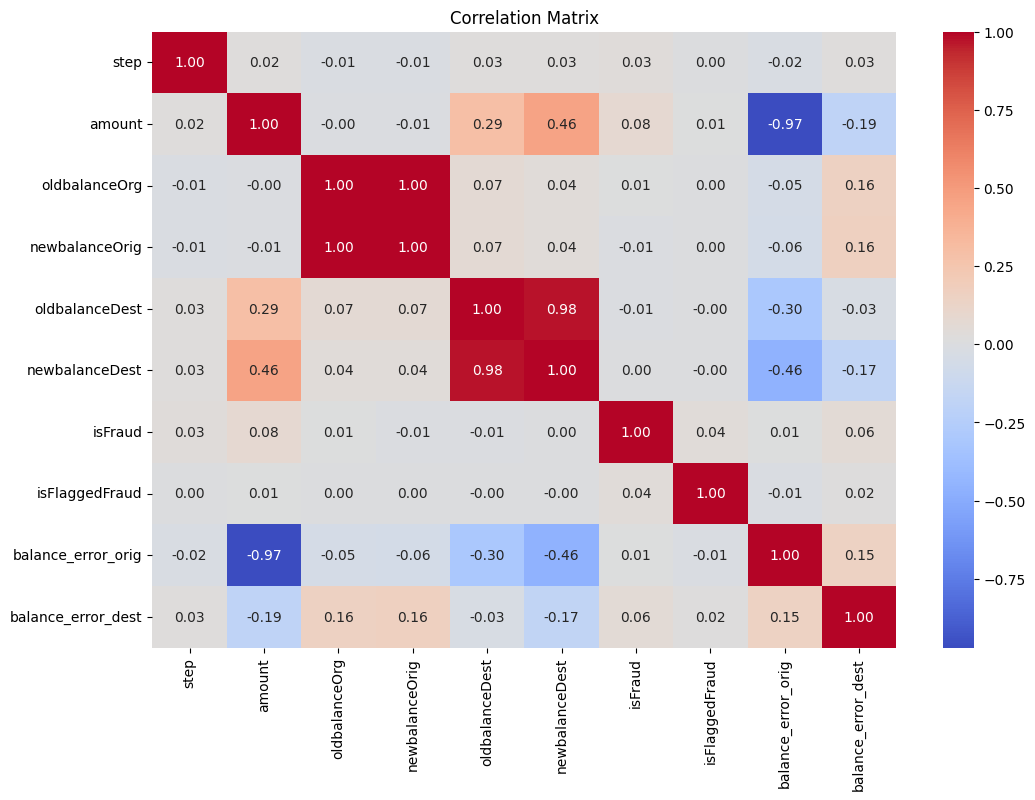

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
df_model = df.drop(
    columns=["nameOrig", "nameDest"]
)

In [ ]:
pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"]
)

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


In [ ]:
X = df_model.drop(columns=["isFraud"])

y = df_model["isFraud"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6362620, 10)
y shape: (6362620,)


# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [ ]:
categorical_features = ["type"]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['type']
Numerical: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'balance_error_orig', 'balance_error_dest']


# Data Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# Linear Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [ ]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'isFlaggedFraud',
                                                   'balance_error_orig',
                                                   'balance_error_dest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred = logistic_model.predict(X_test)

y_proba = logistic_model.predict_proba(X_test)[:, 1]

# Evalulation Metics

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270881
           1       0.03      0.98      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.97      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [ ]:
roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9948784096764255


In [ ]:
pr_auc = average_precision_score(
    y_test,
    y_proba
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.5933509173087436


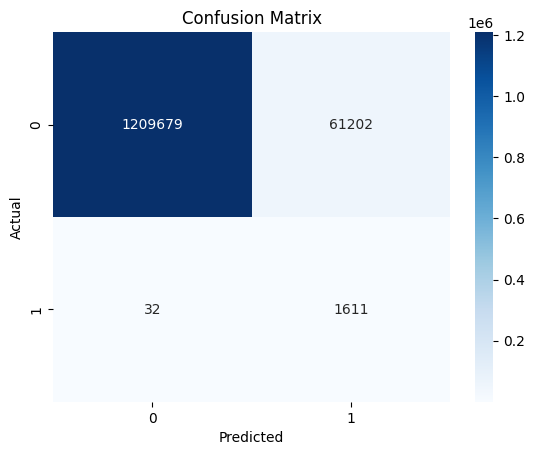

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Random Forest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

In [ ]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'isFlaggedFraud',
                                                   'balance_error_orig',
                                                   'balance_error_dest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
rf_pred = rf_model.predict(X_test)

rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_proba)
)

print(
    "PR-AUC:",
    average_precision_score(y_test, rf_proba)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9987813678403411
PR-AUC: 0.9975685724523045


In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model, pred, proba in [
    (
        "Logistic Regression",
        logistic_model,
        y_pred,
        y_proba
    ),
    (
        "Random Forest",
        rf_model,
        rf_pred,
        rf_proba
    )
]:

    results.append({
        "Model": name,
        "Precision": precision_score(
            y_test,
            pred
        ),
        "Recall": recall_score(
            y_test,
            pred
        ),
        "F1": f1_score(
            y_test,
            pred
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            proba
        ),
        "PR-AUC": average_precision_score(
            y_test,
            proba
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.025648,0.980523,0.049988,0.994878,0.593351
1,Random Forest,1.000000,0.997565,0.998781,0.998781,0.997569


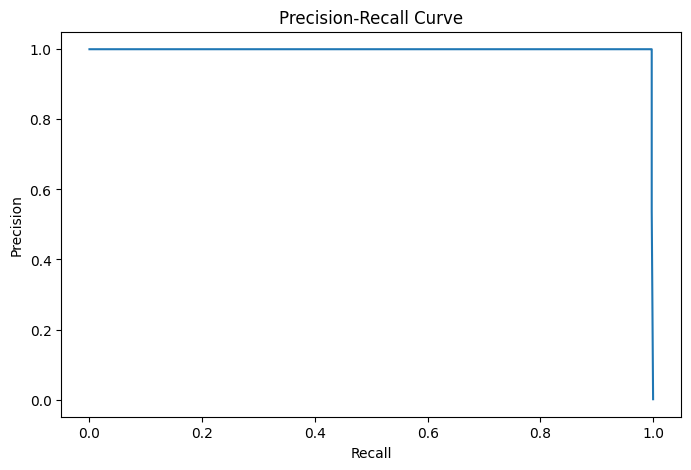

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_proba
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

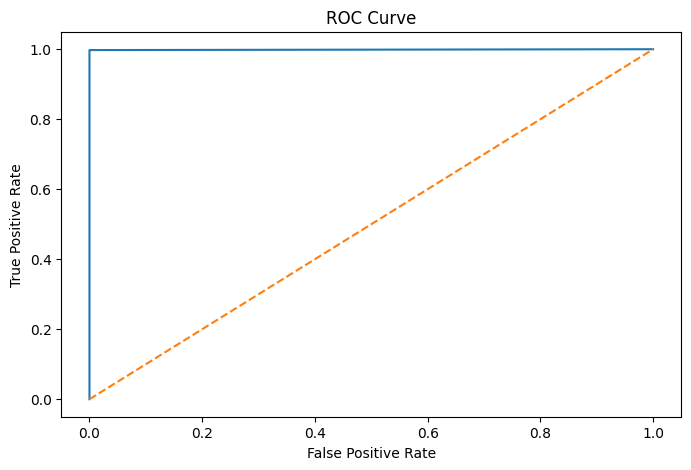

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_proba
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

# Important Features

In [ ]:
rf_classifier = rf_model.named_steps[
    "classifier"
]

feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.head(20)
)

,Feature,Importance
7,num__balance_error_orig,0.366417
3,num__newbalanceOrig,0.158882
2,num__oldbalanceOrg,0.126420
1,num__amount,0.080856
12,cat__type_PAYMENT,0.064140
13,cat__type_TRANSFER,0.053738
0,num__step,0.030366
8,num__balance_error_dest,0.029523
5,num__newbalanceDest,0.024387
10,cat__type_CASH_OUT,0.024205
